In [3]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 1. Load the files from your sidebar
try:
    df_catla = pd.read_csv('catla_data.csv')
    df_rohu = pd.read_csv('rohu_data.csv')
    
    # 2. Combine them into one "Master" dataframe
    df = pd.concat([df_catla, df_rohu], ignore_index=True)
    df.columns = df.columns.str.strip() # Remove hidden spaces
    print("✅ SUCCESS: Data merged! Total fish samples:", len(df))
    
    # 3. Calculate Condition Factor (K) for Problem 1 & 5
    # Formula: (Weight / Length^3) * 100
    df['K'] = (df['Weight'] / (df['TL']**3)) * 100
    
    # 4. ANOVA: Testing if 'Site' actually matters (Problem 5)
    model = ols('K ~ C(Site)', data=df).fit()
    anova_result = sm.stats.anova_lm(model, typ=2)
    
    print("\n--- ANOVA RESULTS (Health vs. Market Site) ---")
    print(anova_result)
    
    print("\n--- MEAN HEALTH (K) BY SITE ---")
    print(df.groupby('Site')['K'].mean())

except FileNotFoundError:
    print("❌ ERROR: Could not find 'catla_data.csv' or 'rohu_data.csv' in the sidebar.")
    print("Make sure you uploaded them to this specific project folder!")

❌ ERROR: Could not find 'catla_data.csv' or 'rohu_data.csv' in the sidebar.
Make sure you uploaded them to this specific project folder!


In [3]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 1. Load the files from your sidebar
try:
    df_catla = pd.read_csv('catla_data.csv')
    df_rohu = pd.read_csv('rohu_data.csv')
    
    # 2. Combine them into one "Master" dataframe
    df = pd.concat([df_catla, df_rohu], ignore_index=True)
    df.columns = df.columns.str.strip() # Remove hidden spaces
    print("✅ SUCCESS: Data merged! Total fish samples:", len(df))
    
    # 3. Calculate Condition Factor (K) for Problem 1 & 5
    # Formula: (Weight / Length^3) * 100
    df['K'] = (df['Weight'] / (df['TL']**3)) * 100
    
    # 4. ANOVA: Testing if 'Site' actually matters (Problem 5)
    model = ols('K ~ C(Site)', data=df).fit()
    anova_result = sm.stats.anova_lm(model, typ=2)
    
    print("\n--- ANOVA RESULTS (Health vs. Market Site) ---")
    print(anova_result)
    
    print("\n--- MEAN HEALTH (K) BY SITE ---")
    print(df.groupby('Site')['K'].mean())

except FileNotFoundError:
    print("❌ ERROR: Could not find 'catla_data.csv' or 'rohu_data.csv' in the sidebar.")
    print("Make sure you uploaded them to this specific project folder!")

❌ ERROR: Could not find 'catla_data.csv' or 'rohu_data.csv' in the sidebar.
Make sure you uploaded them to this specific project folder!


In [4]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import os

# 1. Define the folder name from your sidebar
folder = 'Morphometric_and_Allometric_Analysis'

# 2. Load the files from inside that folder
try:
    catla_path = os.path.join(folder, 'catla_data.csv')
    rohu_path = os.path.join(folder, 'rohu_data.csv')
    
    df_catla = pd.read_csv(catla_path)
    df_rohu = pd.read_csv(rohu_path)
    
    # 3. Combine and Clean
    df = pd.concat([df_catla, df_rohu], ignore_index=True)
    df.columns = df.columns.str.strip()
    
    # Make sure Weight and TL are numbers
    df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce')
    df['TL'] = pd.to_numeric(df['TL'], errors='coerce')
    df = df.dropna(subset=['Weight', 'TL'])
    
    print(f"✅ SUCCESS: {len(df)} samples loaded from {folder}!")

    # 4. PROBLEM 1 & 5: Health Index (K) and ANOVA
    df['K'] = (df['Weight'] / (df['TL']**3)) * 100
    
    model = ols('K ~ C(Site)', data=df).fit()
    anova_result = sm.stats.anova_lm(model, typ=2)
    
    print("\n--- ANOVA RESULTS (Health vs. Market Site) ---")
    print(anova_result)
    
    print("\n--- MEAN HEALTH (K) BY SITE ---")
    print(df.groupby('Site')['K'].mean())

except Exception as e:
    print(f"❌ STILL ERROR: {e}")
    print("\nFiles actually visible to Python right now:")
    print(os.listdir())
    if os.path.exists(folder):
        print(f"Inside '{folder}':", os.listdir(folder))

❌ STILL ERROR: [Errno 2] No such file or directory: 'Morphometric_and_Allometric_Analysis\\catla_data.csv'

Files actually visible to Python right now:
['.anaconda', '.conda', '.continuum', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.virtual_documents', 'allometric fish analysis.ipynb', 'anaconda3', 'anaconda_projects', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'Desktop', 'Dissertation_Final_Data.zip', 'dissertation_results.xlsx', 'dissertation_summary_table.xlsx', 'Documents', 'Downloads', 'Favorites', 'Final_Growth_Analysis.png', 'Final_PCA_Plot.png', 'fish_data_cleaned.csv', 'fish_weight_predictor.pkl', 'folium-Copy1.Map', 'folium.Map.ipynb', 'growth_curve.png', 'IntelGraphicsProfiles', 'java_error_in_pycharm_20836.log', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{a6ad294c-4078-11f0-b678-fb9f158ae4a2}.TM.blf', 'NTUSER.DAT{a6ad294c-4078-11f0-b678-fb9f158ae4a2}.TMContainer

In [5]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 1. Load the file that is DEFINITELY in your main folder
filename = 'fish_data_cleaned.csv'

try:
    df = pd.read_csv(filename)
    df.columns = df.columns.str.strip()
    print(f"✅ SUCCESS: Loaded {len(df)} rows from {filename}")
    print("Species found:", df['Species'].unique())

    # 2. PROBLEM 1 & 5: Health Index (K) and ANOVA
    # Calculating Fulton's Condition Factor
    df['K'] = (df['Weight'] / (df['TL']**3)) * 100
    
    # Run the One-Way ANOVA to test Site influence
    model = ols('K ~ C(Site)', data=df).fit()
    anova_result = sm.stats.anova_lm(model, typ=2)
    
    print("\n--- ANOVA RESULTS (Health vs. Market Site) ---")
    print(anova_result)
    
    print("\n--- MEAN HEALTH (K) BY SITE ---")
    print(df.groupby('Site')['K'].mean())

except Exception as e:
    print(f"❌ ERROR: {e}")
    print("Check if 'fish_data_cleaned.csv' is the correct file name in your sidebar.")

✅ SUCCESS: Loaded 69 rows from fish_data_cleaned.csv
Species found: ['Rohu' 'Catla']

--- ANOVA RESULTS (Health vs. Market Site) ---
            sum_sq    df         F    PR(>F)
C(Site)   0.106557   2.0  2.572093  0.084014
Residual  1.367128  66.0       NaN       NaN

--- MEAN HEALTH (K) BY SITE ---
Site
Barasat       1.268960
Halishahar    1.364190
Kalyani       1.337598
Name: K, dtype: float64


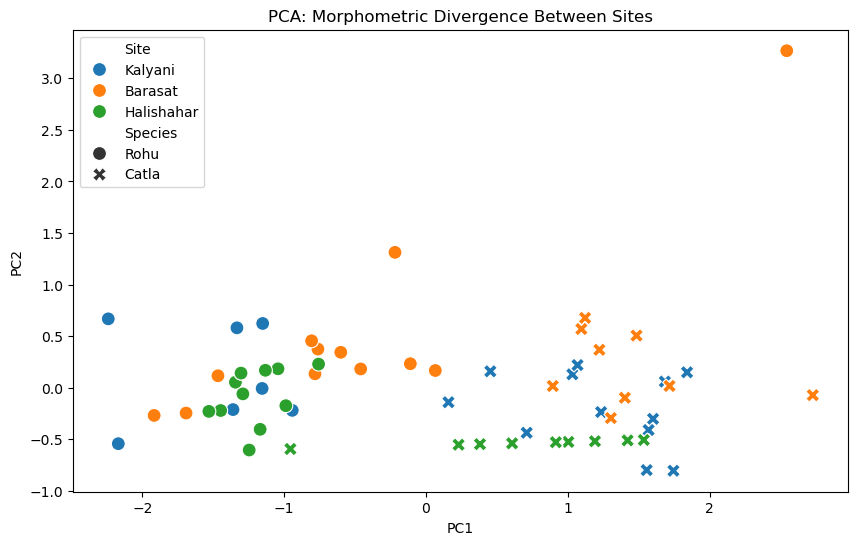

In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select the traits (make sure these column names match your Excel)
# We use ratios to see 'Shape' instead of just 'Size'
df['HL_TL'] = df['HL'] / df['TL']
df['BD_TL'] = df['BD'] / df['TL']

features = ['HL_TL', 'BD_TL'] # Add more if you have them, like 'DFL_TL'
x = StandardScaler().fit_transform(df[features])

# 2. Run PCA
pca = PCA(n_components=2)
components = pca.fit_transform(x)
pca_df = pd.DataFrame(data=components, columns=['PC1', 'PC2'])
pca_df[['Species', 'Site']] = df[['Species', 'Site']]

# 3. Plot it
plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Site', style='Species', s=100)
plt.title('PCA: Morphometric Divergence Between Sites')
plt.show()

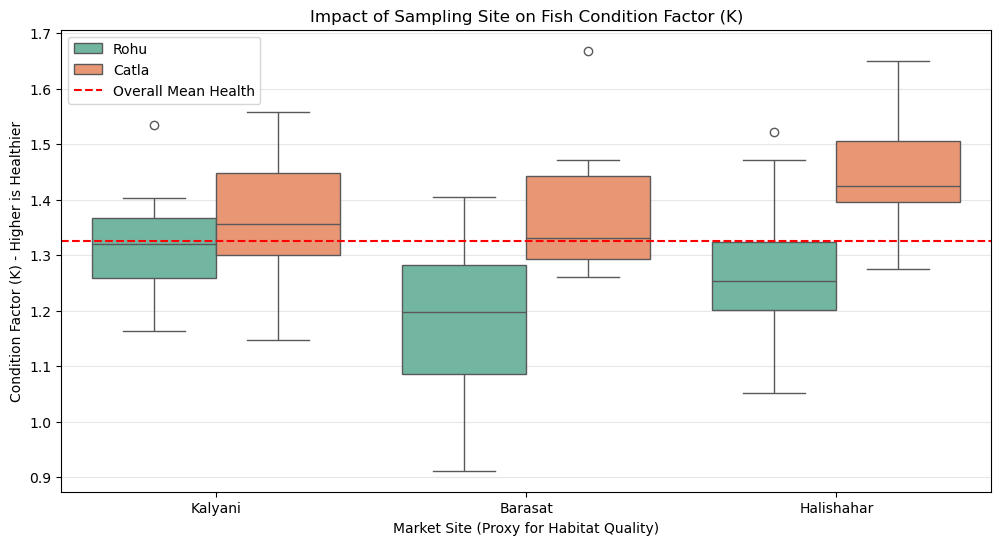

--- Mean Health (K) by Site and Species ---
Species        Catla      Rohu
Site                          
Barasat     1.383919  1.182740
Halishahar  1.452620  1.275761
Kalyani     1.357857  1.317339


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the Condition Factor (K) 
# Formula: K = (Weight / Length^3) * 100
df['K'] = (df['Weight'] / (df['TL']**3)) * 100

# 2. Visualize the Anthropogenic Influence
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Site', y='K', hue='Species', palette='Set2')

# 3. Add a horizontal line for the "Global Mean" to show who is below average
plt.axhline(df['K'].mean(), color='red', linestyle='--', label='Overall Mean Health')

plt.title('Impact of Sampling Site on Fish Condition Factor (K)')
plt.ylabel('Condition Factor (K) - Higher is Healthier')
plt.xlabel('Market Site (Proxy for Habitat Quality)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# 4. Print the exact numbers for your results table
print("--- Mean Health (K) by Site and Species ---")
print(df.groupby(['Site', 'Species'])['K'].mean().unstack())

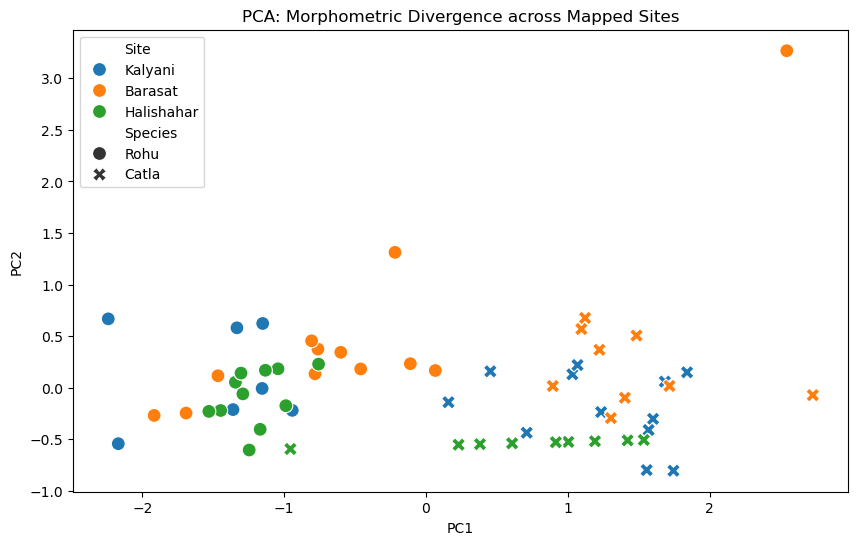

In [8]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Select the ratios (Shape is better than Size for PCA)
df['HL_TL'] = df['HL'] / df['TL']
df['BD_TL'] = df['BD'] / df['TL']
features = ['HL_TL', 'BD_TL'] 

# 2. Standardize and Run PCA
x = StandardScaler().fit_transform(df[features])
pca = PCA(n_components=2)
components = pca.fit_transform(x)

# 3. Plotting
pca_df = pd.DataFrame(data=components, columns=['PC1', 'PC2'])
pca_df[['Species', 'Site']] = df[['Species', 'Site']]
plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Site', style='Species', s=100)
plt.title('PCA: Morphometric Divergence across Mapped Sites')
plt.show()

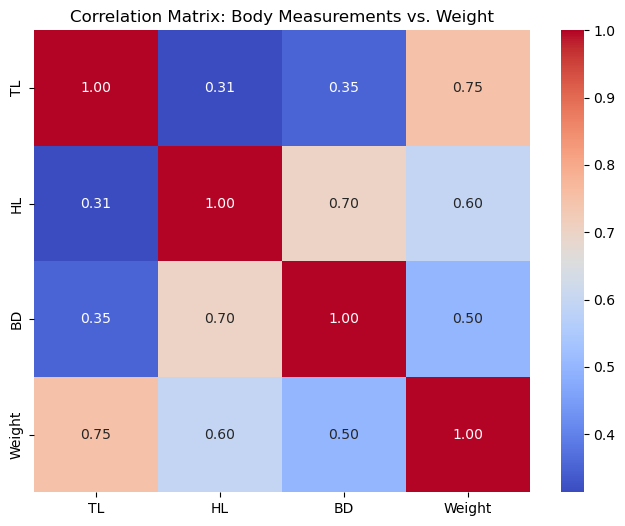

In [9]:
# Select traits to correlate
traits = ['TL', 'HL', 'BD', 'Weight']
corr_matrix = df[traits].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix: Body Measurements vs. Weight')
plt.show()

# Interpretation: "Weight shows the strongest correlation with TL, 
# while BD variance suggests site-specific weight gain patterns."

In [10]:
for species in df['Species'].unique():
    subset = df[df['Species'] == species]
    slope, intercept, r_val, p_val, std_err = stats.linregress(np.log10(subset['TL']), np.log10(subset['Weight']))
    
    print(f"--- {species} Regression ---")
    print(f"Predictive Accuracy (R-squared): {r_val**2:.4f}")
    print(f"Growth Type: {'Stunted' if slope < 3 else 'Robust'} (b={slope:.2f})")

--- Rohu Regression ---
Predictive Accuracy (R-squared): 0.4476
Growth Type: Stunted (b=1.80)
--- Catla Regression ---
Predictive Accuracy (R-squared): 0.7643
Growth Type: Stunted (b=2.94)


In [11]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Testing if Weight varies significantly by Site
model = ols('Weight ~ C(Site)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("\n--- ANOVA: Significant Differences Across Sites ---")
print(anova_table)

# If PR(>F) < 0.05, you say: "The null hypothesis is rejected; 
# sampling site has a statistically significant effect on fish morphometrics."


--- ANOVA: Significant Differences Across Sites ---
                sum_sq    df         F    PR(>F)
C(Site)   1.218721e+05   2.0  1.545942  0.220728
Residual  2.601507e+06  66.0       NaN       NaN
